# Proyecto 2 — Análisis Exploratorio de Ventas

Notebook orientado a cargar, limpiar, resumir y visualizar ventas para obtener hallazgos accionables.

**Objetivo:** construir una evidencia real de análisis de datos para complementar el portafolio.

## 1. Carga de librerías y datos

En esta sección se importan las librerías necesarias y se carga el archivo de ventas para revisar su estructura inicial, tipos de datos y valores faltantes.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Buscar el archivo en una ruta compatible con VS Code Notebook
candidate_paths = [
    Path("src/data/salesData.json"),
    Path("../../src/data/salesData.json"),
]
data_path = next((path for path in candidate_paths if path.exists()), candidate_paths[0])

sales_raw = pd.read_json(data_path)

print(f"Archivo cargado desde: {data_path}")
print(f"Filas originales: {len(sales_raw)}")
print("\nVista previa:")
display(sales_raw.head())
print("\nTipos de datos iniciales:")
display(sales_raw.dtypes)
print("\nValores faltantes por columna:")
display(sales_raw.isna().sum().to_frame("faltantes"))

Archivo cargado desde: ..\..\src\data\salesData.json
Filas originales: 12

Vista previa:


,id,date,product,category,sales,units,region,seller
0,1,2024-01-05,Laptop Pro,Electrónica,1200,1,Norte,Ana
1,2,2024-01-10,Mouse Inalámbrico,Accesorios,35,2,Norte,Ana
2,3,2024-01-12,Teclado Mecánico,Accesorios,80,1,Sur,Pedro
3,4,2024-02-01,Monitor Curvo,Electrónica,450,1,Centro,Sofía
4,5,2024-02-08,Webcam HD,Accesorios,60,3,Norte,Ana



Tipos de datos iniciales:


id                   int64
date        datetime64[us]
product                str
category               str
sales                int64
units                int64
region                 str
seller                 str
dtype: object


Valores faltantes por columna:


,faltantes
id,0
date,0
product,0
category,0
sales,0
units,0
region,0
seller,0


## 2. Limpieza y tipado de columnas

Aquí se normalizan los nombres de columnas, se convierten fechas, se asegura que las columnas numéricas tengan el tipo correcto y se tratan valores nulos o registros incompletos.

In [2]:
df = sales_raw.copy()

# Normalizar nombres de columnas

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
      .str.replace(r"[^a-z0-9_]+", "", regex=True)
)

# Convertir tipos y tratar valores faltantes
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

for col in ["sales", "units"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["product", "category", "seller", "region"]:
    if col in df.columns:
        df[col] = df[col].fillna("Sin dato").astype(str).str.strip()

# Eliminar filas sin información esencial
essential_cols = [col for col in ["date", "sales", "units"] if col in df.columns]
df = df.dropna(subset=essential_cols)

# Rellenar nulos restantes de forma segura
for col in ["sales", "units"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

if "units" in df.columns:
    df["units"] = df["units"].round().astype(int)

# Crear columna auxiliar para análisis mensual
if "date" in df.columns:
    df["month"] = df["date"].dt.to_period("M").astype(str)

print(f"Filas después de la limpieza: {len(df)}")
print("\nTipos de datos finales:")
display(df.dtypes)
print("\nValores faltantes después de la limpieza:")
display(df.isna().sum().to_frame("faltantes"))
print("\nVista previa limpia:")
display(df.head())

Filas después de la limpieza: 12

Tipos de datos finales:


id                   int64
date        datetime64[us]
product                str
category               str
sales                int64
units                int64
region                 str
seller                 str
month                  str
dtype: object


Valores faltantes después de la limpieza:


,faltantes
id,0
date,0
product,0
category,0
sales,0
units,0
region,0
seller,0
month,0



Vista previa limpia:


,id,date,product,category,sales,units,region,seller,month
0,1,2024-01-05,Laptop Pro,Electrónica,1200,1,Norte,Ana,2024-01
1,2,2024-01-10,Mouse Inalámbrico,Accesorios,35,2,Norte,Ana,2024-01
2,3,2024-01-12,Teclado Mecánico,Accesorios,80,1,Sur,Pedro,2024-01
3,4,2024-02-01,Monitor Curvo,Electrónica,450,1,Centro,Sofía,2024-02
4,5,2024-02-08,Webcam HD,Accesorios,60,3,Norte,Ana,2024-02


## 3. Cálculo de KPIs principales

Se calculan métricas clave para resumir el comportamiento general del conjunto de datos y construir un panorama ejecutivo.

In [3]:
kpis = {
    "Ventas totales": df["sales"].sum() if "sales" in df.columns else 0,
    "Unidades vendidas": df["units"].sum() if "units" in df.columns else 0,
    "Productos únicos": df["product"].nunique() if "product" in df.columns else 0,
    "Categorías únicas": df["category"].nunique() if "category" in df.columns else 0,
}

kpi_df = pd.DataFrame(kpis.items(), columns=["Métrica", "Valor"])
display(kpi_df)

print("\nResumen rápido:")
print(f"Ventas promedio por registro: ${df['sales'].mean():,.2f}" if 'sales' in df.columns else "Ventas promedio por registro: N/A")
print(f"Registros analizados: {len(df)}")

,Métrica,Valor
0,Ventas totales,4105
1,Unidades vendidas,15
2,Productos únicos,10
3,Categorías únicas,5



Resumen rápido:
Ventas promedio por registro: $342.08
Registros analizados: 12


## 4. Análisis por categoría, vendedor y mes

Agrupamos la información para identificar los segmentos con mejor rendimiento y los patrones temporales más relevantes.

In [4]:
sales_by_category = (
    df.groupby("category", as_index=False)["sales"].sum().sort_values("sales", ascending=False)
    if "category" in df.columns and "sales" in df.columns
    else pd.DataFrame(columns=["category", "sales"])
)

sales_by_seller = (
    df.groupby("seller", as_index=False)["sales"].sum().sort_values("sales", ascending=False)
    if "seller" in df.columns and "sales" in df.columns
    else pd.DataFrame(columns=["seller", "sales"])
)

sales_by_month = (
    df.groupby("month", as_index=False)["sales"].sum().sort_values("month")
    if "month" in df.columns and "sales" in df.columns
    else pd.DataFrame(columns=["month", "sales"])
)

print("Top 3 categorías:")
display(sales_by_category.head(3))

print("Top 3 vendedores:")
display(sales_by_seller.head(3))

print("Ventas por mes:")
display(sales_by_month)

top_category = sales_by_category.iloc[0] if not sales_by_category.empty else None
top_seller = sales_by_seller.iloc[0] if not sales_by_seller.empty else None
best_month = sales_by_month.iloc[0] if not sales_by_month.empty else None

Top 3 categorías:


,category,sales
3,Electrónica,3300
1,Almacenamiento,240
4,Periféricos,200


Top 3 vendedores:


,seller,sales
2,Sofía,1800
0,Ana,1565
1,Pedro,740


Ventas por mes:


,month,sales
0,2024-01,1315
1,2024-02,630
2,2024-03,1360
3,2024-04,800


## 5. Visualización de hallazgos

Se construyen gráficos de barras y líneas para comunicar claramente los resultados y destacar los principales hallazgos.

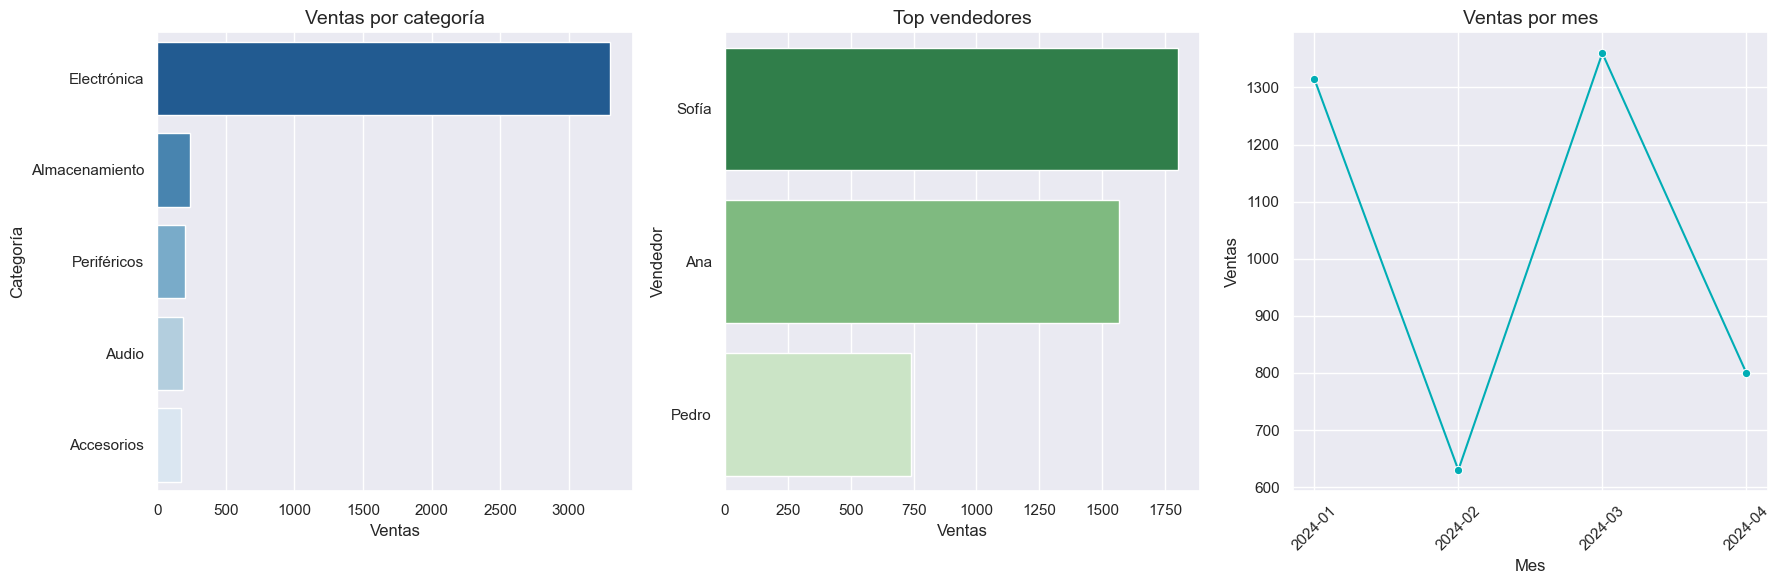


Principales hallazgos:
- Categoría líder: Electrónica con $3,300
- Vendedor destacado: Sofía con $1,800
- Mejor mes: 2024-01 con $1,315


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Ventas por categoría
if not sales_by_category.empty:
    sns.barplot(
        data=sales_by_category,
        x="sales",
        y="category",
        hue="category",
        palette="Blues_r",
        legend=False,
        ax=axes[0],
    )
    axes[0].set_title("Ventas por categoría")
    axes[0].set_xlabel("Ventas")
    axes[0].set_ylabel("Categoría")
else:
    axes[0].text(0.5, 0.5, "Sin datos", ha="center", va="center")
    axes[0].set_axis_off()

# Ventas por vendedor
if not sales_by_seller.empty:
    sns.barplot(
        data=sales_by_seller.head(5),
        x="sales",
        y="seller",
        hue="seller",
        palette="Greens_r",
        legend=False,
        ax=axes[1],
    )
    axes[1].set_title("Top vendedores")
    axes[1].set_xlabel("Ventas")
    axes[1].set_ylabel("Vendedor")
else:
    axes[1].text(0.5, 0.5, "Sin datos", ha="center", va="center")
    axes[1].set_axis_off()

# Ventas por mes
if not sales_by_month.empty:
    sns.lineplot(data=sales_by_month, x="month", y="sales", marker="o", ax=axes[2], color="#00ADB5")
    axes[2].set_title("Ventas por mes")
    axes[2].set_xlabel("Mes")
    axes[2].set_ylabel("Ventas")
    axes[2].tick_params(axis="x", rotation=45)
else:
    axes[2].text(0.5, 0.5, "Sin datos", ha="center", va="center")
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()

print("\nPrincipales hallazgos:")
if top_category is not None:
    print(f"- Categoría líder: {top_category['category']} con ${top_category['sales']:,.0f}")
if top_seller is not None:
    print(f"- Vendedor destacado: {top_seller['seller']} con ${top_seller['sales']:,.0f}")
if best_month is not None:
    print(f"- Mejor mes: {best_month['month']} con ${best_month['sales']:,.0f}")